In [369]:
# Problem 1
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches


In [370]:
# Problem 2
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [371]:
# Problem 3
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [372]:
##Problem 4
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [373]:
# Problem 5
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        if state == self.goal:
            return True
        else:
            return False

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        legal_actions = []

        for action in MOVES:
            dr, dc = MOVES[action]
            row, col = state
            neighbour = (dr + row, dc + col)
            if (self.in_bounds(neighbour)) and (self.is_free(neighbour)):
                legal_actions.append(action)
        return legal_actions

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        dr, dc = MOVES[action]
        row, col = state
        return (row + dr, col + dc)

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        return 1


In [374]:
# Problem 5.1
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


In [375]:
# Problem 6
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

In [376]:
# Problem 7
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

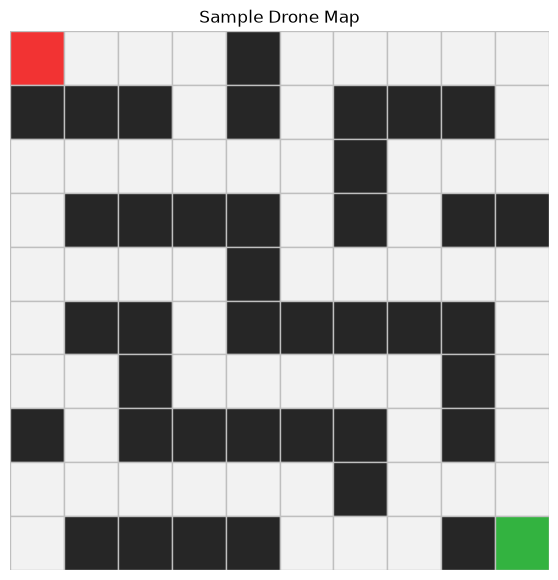

In [377]:
plot_path(sample_grid, start, goal, title="Sample Drone Map")

In [378]:
# Question 8
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        s = node.state
        for action in problem.actions(s):
            s_prime = problem.result(s, action)
            cost = node.path_cost + problem.action_cost(s, action, s_prime)
            yield Node(state=s_prime, parent=node, action=action, path_cost=cost)

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass


In [379]:
# Problem 9
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"

        nodes_expanded = 0
        max_frontier_size = 1

        init_node = Node(problem.initial_state())

        if problem.is_goal(init_node.state):
            return SearchResult(
                algorithm, "success", init_node, nodes_expanded, max_frontier_size
            )

        frontier = deque([init_node])
        reached = {init_node.state}

        while frontier:
            node = frontier.popleft()
            nodes_expanded += 1

            for child in self.expand(problem, node):
                if child.state not in reached:
                    reached.add(child.state)
                    if problem.is_goal(child.state):
                        return SearchResult(
                            algorithm,
                            "success",
                            child,
                            nodes_expanded,
                            max_frontier_size,
                        )
                    frontier.append(child)

            max_frontier_size = max(max_frontier_size, len(frontier))

        return SearchResult(
            algorithm, "failure", None, nodes_expanded, max_frontier_size
        )


In [380]:
# Problem 10
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }
        init_node = Node(problem.initial_state())

        if problem.is_goal(init_node.state):
            return SearchResult(
                algorithm,
                "success",
                init_node,
                metrics["nodes_expanded"],
                metrics["max_stack_size"],
            )

        frontier = [init_node]

        reached = set()
        reached.add(init_node.state)

        while frontier:
            node = frontier.pop()
            metrics["nodes_expanded"] += 1

            if problem.is_goal(node.state):
                return SearchResult(
                    algorithm,
                    "success",
                    node,
                    metrics["nodes_expanded"],
                    metrics["max_stack_size"],
                )

            for child in self.expand(problem, node):
                if child.state not in reached:
                    reached.add(child.state)
                    frontier.append(child)

            metrics["max_stack_size"] = max(metrics["max_stack_size"], len(frontier))

        return SearchResult(
            algorithm,
            "failure",
            None,
            metrics["nodes_expanded"],
            metrics["max_stack_size"],
        )


In [381]:
# Problem 11
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        initial_node = Node(problem.initial_state())
        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:

        if problem.is_goal(node.state):
            return (node, "success")

        elif node.depth >= limit:
            return (None, "cutoff")

        cutoff_occurred = False
        metrics["nodes_expanded"] += 1

        for child in self.expand(problem, node):
            if state_is_on_path(node, child.state):
                continue

            metrics["max_stack_size"] = max(
                metrics["max_stack_size"], current_stack_size + 1
            )
            child_solution, status = self._recursive_dls(
                problem,
                child,
                limit,
                metrics,
                current_stack_size + 1,
            )

            if status == "success":
                return (child_solution, "success")

            if status == "cutoff":
                cutoff_occurred = True

        if cutoff_occurred:
            return (None, "cutoff")
        else:
            return (None, "failure")


In [382]:
# Problem 12


class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        iteration_log = []
        dls = DepthLimitedSearch()

        # result = dls.search(problem, limit=limit)

        for limit in range(max_depth + 1):
            result = dls.search(problem, limit=limit)
            iteration_log.append(result)

            if result.status == "success":
                return SearchResult(
                    algorithm,
                    "success",
                    None,
                    metrics["nodes_expanded"],
                    metrics["max_stack_size"],
                )

            elif result.status == "failure":
                return SearchResult(
                    algorithm,
                    "failure",
                    None,
                    metrics["nodes_expanded"],
                    metrics["max_stack_size"],
                )

        return SearchResult(
            algorithm,
            "cutoff",
            None,
            metrics["nodes_expanded"],
            metrics["max_stack_size"],
        )

In [383]:
# Problem 13
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

for i, r in enumerate(results):
    print(i, type(r), r)

show_results(results)

0 <class '__main__.SearchResult'> SearchResult(algorithm='BFS', status='success', solution=Node(state=(9, 9), parent=Node(state=(8, 9), parent=Node(state=(7, 9), parent=Node(state=(6, 9), parent=Node(state=(5, 9), parent=Node(state=(4, 9), parent=Node(state=(4, 8), parent=Node(state=(4, 7), parent=Node(state=(4, 6), parent=Node(state=(4, 5), parent=Node(state=(3, 5), parent=Node(state=(2, 5), parent=Node(state=(2, 4), parent=Node(state=(2, 3), parent=Node(state=(1, 3), parent=Node(state=(0, 3), parent=Node(state=(0, 2), parent=Node(state=(0, 1), parent=Node(state=(0, 0), parent=None, action=None, path_cost=0, depth=0), action='RIGHT', path_cost=1, depth=1), action='RIGHT', path_cost=2, depth=2), action='RIGHT', path_cost=3, depth=3), action='DOWN', path_cost=4, depth=4), action='DOWN', path_cost=5, depth=5), action='RIGHT', path_cost=6, depth=6), action='RIGHT', path_cost=7, depth=7), action='DOWN', path_cost=8, depth=8), action='DOWN', path_cost=9, depth=9), action='RIGHT', path_cost=

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,18.0,18.0,50,5,0
1,DFS,success,NaN,18.0,18.0,49,7,0
2,DLS,cutoff,10.0,NaN,NaN,16,11,0
3,IDS,success,NaN,NaN,NaN,0,1,0


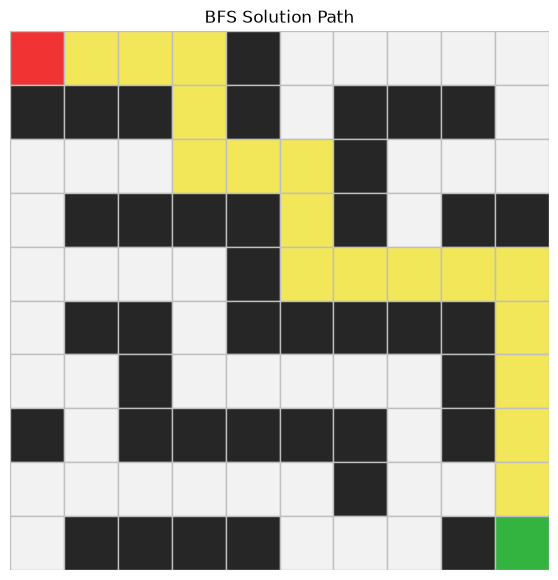

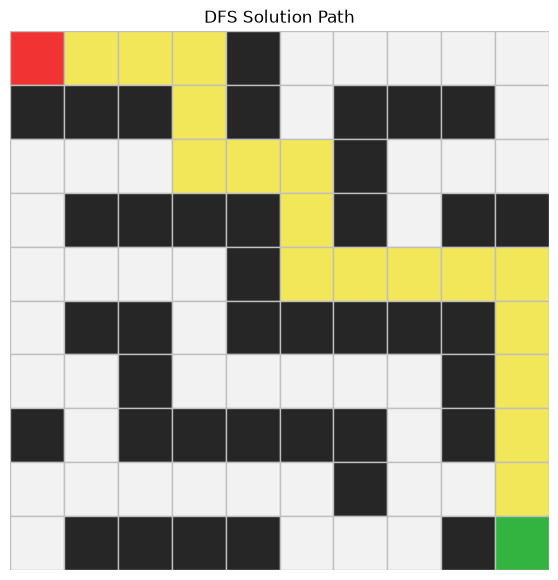

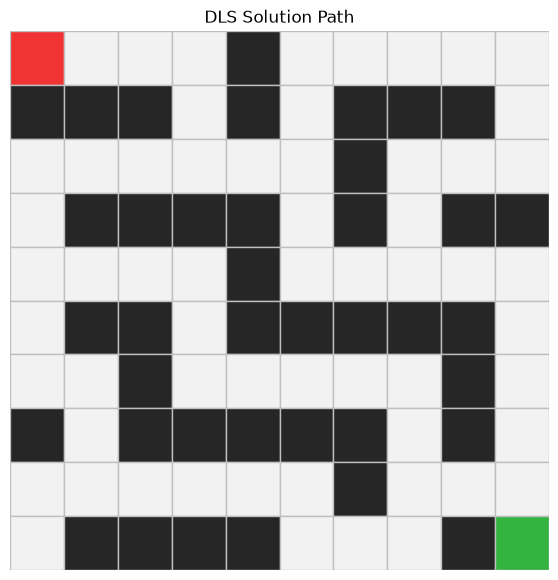

In [384]:
bfs_result = results[0]
dfs_result = results[1]
dls_result = results[2]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dls_result.path,
    title="DLS Solution Path",
)

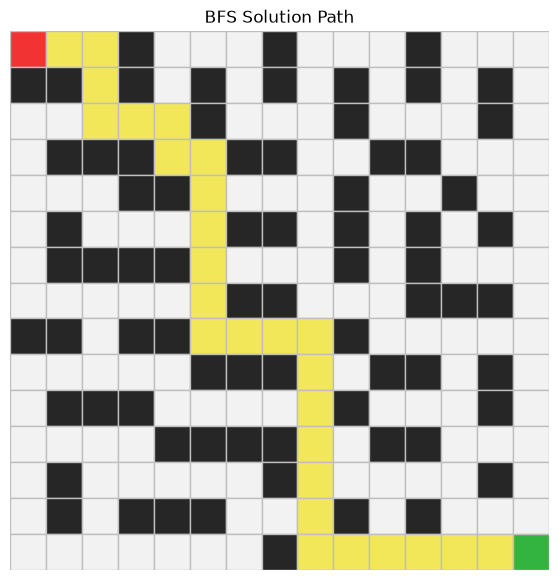

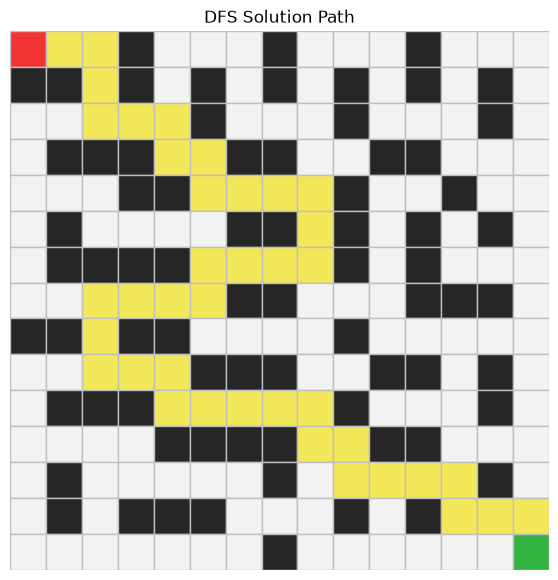

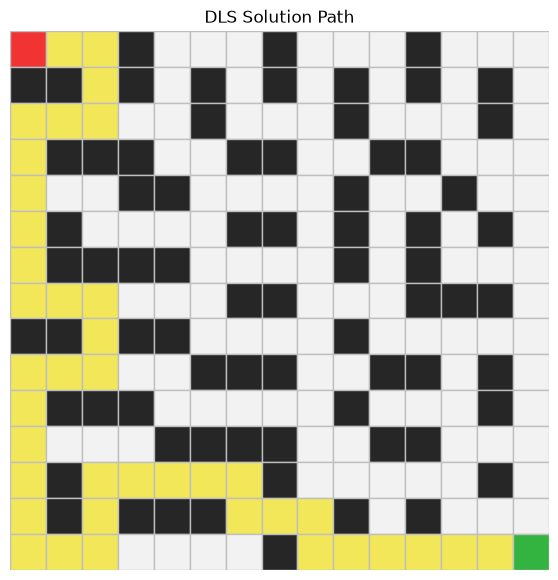

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,28.0,28.0,148,13,0
1,DFS,success,NaN,40.0,40.0,53,15,0
2,DLS,success,40.0,40.0,40.0,115,41,0
3,IDS,success,NaN,NaN,NaN,0,1,0


In [385]:
# Problem 10
custom_results_1 = results[0]
custom_results_2 = results[1]

custom_grid_1 = [
    [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0],
    [1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0],
    [0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0],
    [1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0],
    [0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
]

custom_start_1 = (0, 0)
custom_goal_1 = (14, 14)

custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=40),
    ids.search(custom_problem_1, max_depth=40),
]

plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=custom_results_1[0].path,
    title="BFS Solution Path",
)

plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=custom_results_1[1].path,
    title="DFS Solution Path",
)

plot_path(
    custom_grid_1,
    custom_start_1,
    custom_goal_1,
    path=custom_results_1[2].path,
    title="DLS Solution Path",
)

show_results(custom_results_1)


In [ ]:
# Interpretation for custom grid 1
# On this medium 15×15 map, BFS systematically expands outward from the start and reliably finds a shortest
# (fewest-steps) route but explores many frontier states first; DFS dives deep along a branch so it can reach the goal
# faster in some runs but typically returns a longer/non-optimal path and is sensitive to neighbor ordering; DLS behaves
# like DFS with a cutoff — a too-small limit produced a cutoff (no path), but raising the limit (we used 40) allowed a
# valid path to be found; IDS repeats DLS with increasing limits to combine DFS memory efficiency with the guarantee
# of finding shallow solutions.
#

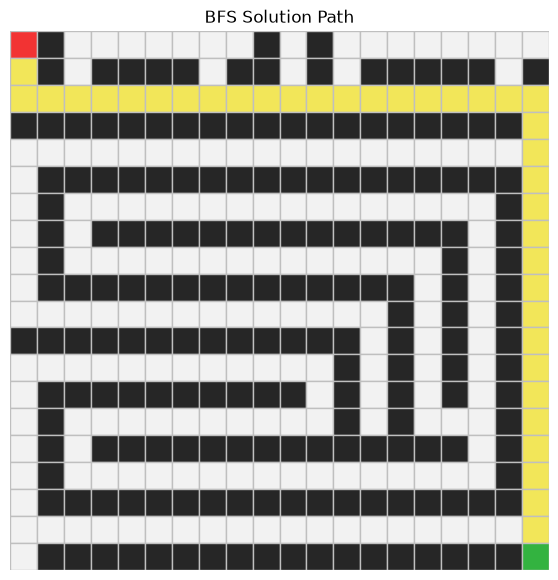

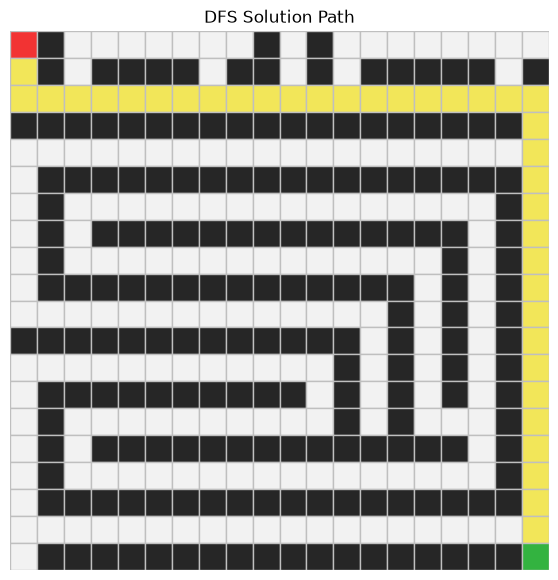

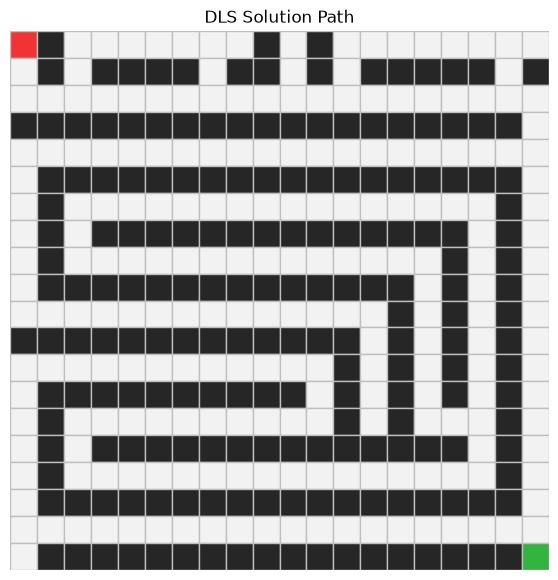

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,38.0,38.0,72,3,0
1,DFS,success,NaN,38.0,38.0,193,8,0
2,DLS,cutoff,20.0,NaN,NaN,59,21,0
3,IDS,success,NaN,NaN,NaN,0,1,0


In [ ]:
custom_grid_2 = [
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0],
    [0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
]

custom_start_2 = (0, 0)
custom_goal_2 = (19, 19)

custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
custom_results_2 = [
    bfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
    dls.search(custom_problem_2, limit=20),
    ids.search(custom_problem_2, max_depth=40),
]

plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=custom_results_2[0].path,
    title="BFS Solution Path",
)

plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=custom_results_2[1].path,
    title="DFS Solution Path",
)

plot_path(
    custom_grid_2,
    custom_start_2,
    custom_goal_2,
    path=custom_results_2[2].path,
    title="DLS Solution Path",
)

show_results(custom_results_2)


In [ ]:
# Intepretation for custom grid 2
# The larger, dense-obstacle 20×20 grid stresses breadth-first strategies
# (BFS finds the shortest path but with higher memory use), while DFS can still
# find a path quickly because it follows single branches (our test found a DFS
# path of length 39); DLS may be cutoff at modest limits on this map — increase
# the depth limit if DLS fails; overall, choose BFS when you need shortest paths
# and can afford memory, DFS/DLS/IDS when memory is constrained or when you want
# faster-but-not-necessarily-short routes.

In [ ]:
# Reflection Questions
# 15.1
# 1. A state is the condition of an environment at a given time
# 2.It is step or decision taken by the agent
# 3.It represents the final decision or response of the agent
# 4.It allows algorithms to be swapped for performance optimization
#
#
# 15.2
# 1. To guarantee the nodes are visited in order of their distance from the starting Node
# 2. Because it explores nodes in order of their distance from the starting point
# 3. It shows the nodes that have already been expanded on
#
#
# 15.3
# 2. No, it is not guaranteed to find the shortest path. This is because since it goes deep into
# every path before backtracking, it returns the first path to the destination.
# 3. In the situation of wide, shallow trees with a high branching factor and a shallow solution DepthFirstSearch
# 4. In the case of infinite depth or extreme tree depth.
#
#
# 15.4
# 1. When the depth is too small, the algorithm becomes incomplete
# 2. It is the limit of how deep the algorithm can explore a search tree
# 3. DLS is a modified version of DFS that introduces a maximum depth constraint to prevent the
# algorithm from getting stuck in infinite paths
# 4.To prevent the algorithm from wasting time and memory exploring the same sequence of nodes within
# a single path
#
#
# 15.5
# 1. To combine low memory benefits of dfs with the guaranteed optimality of bfs
# 2. IDS acheives completeness because it does not stick to a single, static limit.
# 3. It is because of how nodes are stored during the search process.
# 4. It leads to an increase in time complexity due to revisiting of upper-level nodes

# 15.6
# 1. Population density and urban risks, obstacle clearance and topography, and environmental and weather dynamics.
# 2. BFS. Because it expands uniformly, and it does not waste time calculating complex path costs because depth and
# cost are perfectly correlated
# 3. For limits, the best algortihm is DLS. This is because it is specifically designed to accept a hard boundaries
# parameter, that is, the depth limit.
# 4. For this model, the drone moves step-by-step, failing to capture the physical and regulatory complexities of
# actual flight